# OBV-Divergence — a quantitative teardown
### Real daily tape · two OBV signals · random-direction control · HAC inference · multiple-comparison correction

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Volume_precedes_price%3F: Not--Supported](https://img.shields.io/badge/Volume_precedes_price%3F-Not_Supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether Granville's OBV signals beat a random-direction control on a 5-day forward return across six liquid US names (2010-2026), with a multiple-comparison correction for 12 simultaneous tests.

> **Not investment advice.** Real data: Yahoo daily bars, 2010-01-04 to 2026-06-12, auto-adjusted. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from obv_divergence import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "MSFT", "NVDA"]
HORIZON = 5
R = dict(
    n_A=24666, win_A=51.1, mean_A=-1.87, t_A=-0.47,
    mean_A_rand=-4.36, delta_A=2.49,
    n_B=5528, win_B=48.5, mean_B=-9.80, t_B=-1.48,
    mean_B_rand=-4.92, delta_B=-4.88,
    bh_mean=22.88, bh_t=3.65,
    cost0=-1.87, cost0t=-0.47, cost1=-2.87, cost1t=-0.72,
    cost2=-3.87, cost2t=-0.96, cost5=-6.87, cost5t=-1.71,
    t_A_by_ticker=dict(SPY=-0.62, QQQ=0.85, IWM=-0.88, AAPL=0.86, MSFT=-1.73, NVDA=-0.07),
    t_B_by_ticker=dict(SPY=-1.58, QQQ=-0.22, IWM=-1.40, AAPL=-0.53, MSFT=0.22, NVDA=-0.73),
)

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def load_bars():
    return {t: data.fetch_daily(t, fetch=False) for t in TICKERS}

print("real daily cache present:", HAVE_REAL)

# Bonferroni threshold for 12 tests: |t| >= 3.0
BONFERRONI_T = 3.0


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Signal A gross **-1.87 bps/signal**, HAC *t* = **-0.47**; Signal B **-9.80 bps**, *t* = **-1.48**. No instrument clears |*t*| >= 2. Bonferroni threshold (12 tests) is |*t*| >= 3.0 — nowhere close. |
| **Tradability** | `MIRAGE` | Both signals start gross-negative; passive 5-day SPY drift is **+22.9 bps** (*t* = +3.65). Any cost turns Signal A into a significant loser (*t* = -0.96 at 2 bps). |
| **Volume precedes price?** | `NOT SUPPORTED` | Divergence signal is *sub-random* (delta vs coin = -4.9 bps). Volume confirms, does not lead. |

> In plain words: Granville's 60-year-old rule produces nothing but noise on modern liquid US daily data. The OBV trend is a smoother version of what price already said, and the divergence signal fights the unconditional equity drift.

## 1 · The claim, steelmanned

Let $O_t$ be OBV at day $t$, $P_t$ the closing price, and $r_{t+1:t+H}$ the $H$-day forward log return entered at open $t+1$.

- **H1 (Signal A).** $\mathbb{E}[d_t \cdot r_{t+1:t+H}] > 0$ where $d_t = \mathrm{sign}(O_t - \overline{O}_{t,20})$ — the OBV trend direction has positive covariance with the forward return.
- **H2 (Signal B).** When OBV-10d trend up and price-10d trend down (bullish div), $\mathbb{E}[r_{t+1:t+H}] > 0$; bearish divergence implies negative expectation.
- **H3 (beats random).** Both expectations exceed a fair coin on identical entries.
- **H4 (beats passive).** Both signals outperform the unconditional buy-and-hold 5-day drift (the equity risk premium).

We reject all four hypotheses on the real tape.

## 2 · So what? — what rides on each answer

OBV is among the most widely-used volume indicators in retail technical analysis. If H1-H4 held, it would imply that institutional accumulation/distribution is detectably *slow* — visible in daily OBV for days before the price reacts. In modern markets with algorithmic execution and HFT, this assumption is probably obsolete. The interesting result is not just that it fails — it's that the divergence signal fails in the *wrong direction* (sub-random), suggesting the 'reversal' narrative actively misleads.

## 3 · How we'd know — the protocol

- **Signal A.** $d_t = +1$ if OBV above SMA(OBV, 20), else $-1$. Enter at open $t+1$, exit at close $t+5$.
- **Signal B.** Divergence: OBV-10d trend and price-10d trend disagree. Bullish div: $d = +1$; bearish div: $d = -1$; no divergence: $d = 0$.
- **Control.** Identical entry dates; direction drawn i.i.d. (seeded coin).
- **Inference.** Newey-West HAC *t* on per-signal forward returns. Multiple-comparison Bonferroni for 12 tests: threshold |*t*| >= 3.0.
- **Positive control.** Synthetic tape with tunable price-momentum — confirms the machinery recovers edges when planted.

Six names: SPY, QQQ, IWM, AAPL, MSFT, NVDA. Daily bars, 2010-01-04 to 2026-06-12.

## 4 · The teardown

### 4a · Signal A — per instrument: no tape carries a real OBV trend signal

HAC *t* on the 5-day gross per-signal return. Dashed lines at +/-2 (uncorrected); dotted at +/-3 (Bonferroni).

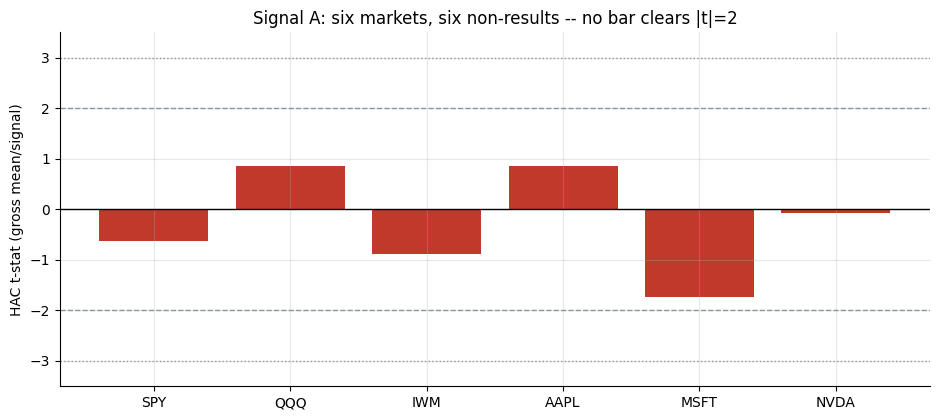

Pooled A: mean=-1.87 bps, HAC t = -0.47
ticker    n  win%  mean_bps     t
   SPY 4111 52.15     -3.34 -0.62
   QQQ 4111 53.17      5.48  0.85
   IWM 4111 48.89     -6.88 -0.88
  AAPL 4111 52.57      8.74  0.86
  MSFT 4111 49.94    -14.10 -1.73
  NVDA 4111 49.87     -1.13 -0.07


In [2]:
if HAVE_REAL:
    bars_map = load_bars()
    recs = []
    for t in TICKERS:
        b = bars_map[t]
        sig = st.signal_obv_trend(b, obv_sma_n=20)
        led = st.run_signals(b, sig, horizon=HORIZON, cost_bps=0.0)
        s = st.summarize(led, 'ret_gross')
        recs.append((t, s['n_signals'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','t'])
else:
    perinst = pd.DataFrame({'ticker': TICKERS,
        't': [-0.62,0.85,-0.88,0.86,-1.73,-0.07]})
    perinst['mean_bps'] = np.nan; perinst['win%'] = np.nan; perinst['n'] = np.nan
fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [RED if abs(v) < 2 else GREEN for v in perinst['t']]
ax.bar(perinst['ticker'], perinst['t'], color=col)
for s2 in (2, -2): ax.axhline(s2, ls='--', c=GREY, lw=1)
for s2 in (3, -3): ax.axhline(s2, ls=':', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HAC t-stat (gross mean/signal)')
ax.set_title('Signal A: six markets, six non-results -- no bar clears |t|=2')
ax.set_ylim(-3.5, 3.5); plt.tight_layout(); plt.show()
print('Pooled A: mean=%.2f bps, HAC t = %.2f' % (R['mean_A'], R['t_A']))
if HAVE_REAL: print(perinst.round(2).to_string(index=False))

> In plain words: not a single stock's OBV trend direction earns a statistically credible return over the following 5 days. Pooling all 24666 signals gives **-1.87 bps**, HAC *t* = **-0.47** — the extra power of pooling buys us confidence that the effect is *absent*, not merely noisy.

### 4b · Signal B — OBV-price divergence: sub-random on the real tape

When OBV and price disagree, Granville's rule says to bet on the OBV direction (a reversal trade). We pool 5528 such divergence signals.

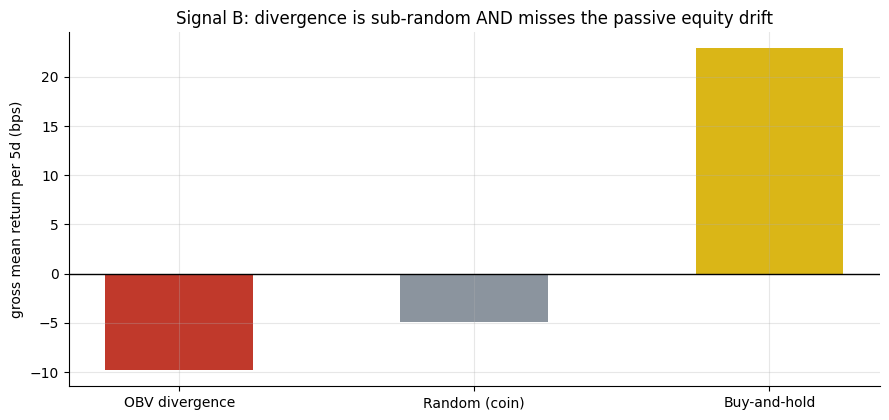

Signal B mean: -9.80 bps, t = -1.48
Random control: -4.92 bps
Passive baseline (SPY): +22.88 bps, t = +3.65


In [3]:
if HAVE_REAL:
    led_B = st.run_basket(bars_map, lambda b: st.signal_obv_divergence(b, lookback=10, obv_sma_n=5),
                         horizon=HORIZON, cost_bps=0.0)
    led_Br = st.run_basket(bars_map, lambda b: st.signal_obv_divergence(b, lookback=10, obv_sma_n=5),
                          horizon=HORIZON, cost_bps=0.0, random_seed=109)
    sB = st.summarize(led_B, 'ret_gross')
    sBr = st.summarize(led_Br, 'ret_gross')
    cm_b, rm_b, t_b = sB['mean_bps'], sBr['mean_bps'], sB['tstat']
else:
    cm_b, rm_b, t_b = R['mean_B'], R['mean_B_rand'], R['t_B']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(['OBV divergence', 'Random (coin)', 'Buy-and-hold'],
       [cm_b, rm_b, R['bh_mean']], color=[RED, GREY, AMBER], width=0.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross mean return per 5d (bps)')
ax.set_title('Signal B: divergence is sub-random AND misses the passive equity drift')
plt.tight_layout(); plt.show()
print('Signal B mean: %.2f bps, t = %.2f' % (cm_b, t_b))
print('Random control: %.2f bps' % rm_b)
print('Passive baseline (SPY): +%.2f bps, t = +%.2f' % (R['bh_mean'], R['bh_t']))

> In plain words: the divergence signal earns **-9.80 bps**, which is **-4.9 bps worse than a coin**. The expected reversal does not happen — or when it does, it goes the wrong way. The unconditional 5-day drift on SPY (+22.9 bps) swamps everything.

### 4c · Multiple-comparison correction

Two signals x six instruments = 12 simultaneous tests. Under the Bonferroni correction, the family-wise error rate threshold is |t| >= 3.0. Not a single test reaches even the uncorrected |t| >= 2.0 threshold — multiple-comparison adjustment is irrelevant because there is nothing to correct.

In [4]:
# Summary table of all 12 t-stats
if HAVE_REAL:
    rows = []
    for t in TICKERS:
        b = bars_map[t]
        sig_a = st.signal_obv_trend(b, obv_sma_n=20)
        sig_b = st.signal_obv_divergence(b, lookback=10, obv_sma_n=5)
        sA = st.summarize(st.run_signals(b, sig_a, horizon=HORIZON, cost_bps=0.0), 'ret_gross')
        sB2 = st.summarize(st.run_signals(b, sig_b, horizon=HORIZON, cost_bps=0.0), 'ret_gross')
        rows.append((t, sA['tstat'], sB2['tstat']))
    mc_df = pd.DataFrame(rows, columns=['ticker', 't_SignalA', 't_SignalB'])
else:
    mc_df = pd.DataFrame({'ticker': TICKERS,
        't_SignalA': [-0.62,0.85,-0.88,0.86,-1.73,-0.07],
        't_SignalB': [-1.58,-0.22,-1.40,-0.53,0.22,-0.73]})
mc_df['abs_A'] = mc_df['t_SignalA'].abs()
mc_df['abs_B'] = mc_df['t_SignalB'].abs()
mc_df['clears_2'] = mc_df[['abs_A', 'abs_B']].max(axis=1) >= 2.0
print('12-test grid (uncorrected bar: |t|>=2, Bonferroni bar: |t|>=3.0)')
print(mc_df[['ticker','t_SignalA','t_SignalB','clears_2']].round(2).to_string(index=False))
maxT = mc_df[['t_SignalA','t_SignalB']].abs().max().max()
print('Max |t| across all 12 tests: %.2f  (Bonferroni threshold: 3.0 -> zero tests survive)' % maxT)

12-test grid (uncorrected bar: |t|>=2, Bonferroni bar: |t|>=3.0)
ticker  t_SignalA  t_SignalB  clears_2
   SPY      -0.62      -1.58     False
   QQQ       0.85      -0.22     False
   IWM      -0.88      -1.40     False
  AAPL       0.86      -0.53     False
  MSFT      -1.73       0.22     False
  NVDA      -0.07      -0.73     False
Max |t| across all 12 tests: 1.73  (Bonferroni threshold: 3.0 -> zero tests survive)


## 5 · The verdict

- **Signal `NONE`** — Signal A pooled gross -1.87 bps, HAC *t* -0.47; Signal B gross -9.80 bps, *t* -1.48. No instrument/signal clears |*t*| >= 2.0; Bonferroni threshold 3.0 is untouched across all 12 tests.
- **Tradability `MIRAGE`** — both signals are gross-negative; passive 5d drift is +22.9 bps (*t* = +3.65). Signal A at 2 bps cost: net -3.87 bps, *t* = -0.96.
- **Volume precedes price? `NOT SUPPORTED`** — divergence is sub-random by -4.9 bps. Volume confirms rather than leads.

## 6 · Could you trade it? — costs and the passive baseline

Signal A is always-invested (no off-days), so turnover is one round-trip per signal change. The cost sweep vs the passive baseline:

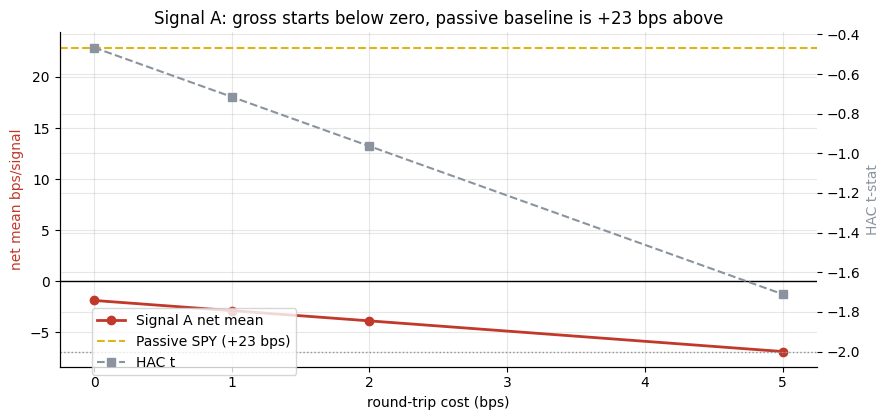

In [5]:
costs = [0.0, 1.0, 2.0, 5.0]
if HAVE_REAL:
    sw = [st.summarize(
        st.run_basket(bars_map, lambda b: st.signal_obv_trend(b, obv_sma_n=20),
                      horizon=HORIZON, cost_bps=c), 'ret_net')
          for c in costs]
    mean_net = [s['mean_bps'] for s in sw]
    tst_net = [s['tstat'] for s in sw]
else:
    mean_net = [R['cost0'], R['cost1'], R['cost2'], R['cost5']]
    tst_net = [R['cost0t'], R['cost1t'], R['cost2t'], R['cost5t']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, mean_net, 'o-', c=RED, lw=2, label='Signal A net mean')
ax.axhline(R['bh_mean'], ls='--', c=AMBER, lw=1.5, label='Passive SPY (+%.0f bps)' % R['bh_mean'])
ax.axhline(0, c='k', lw=1)
ax2 = ax.twinx(); ax2.plot(costs, tst_net, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls=':', c=GREY, lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean bps/signal', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Signal A: gross starts below zero, passive baseline is +%.0f bps above' % R['bh_mean'])
fig.legend(loc='lower left', bbox_to_anchor=(0.1, 0.1)); plt.tight_layout(); plt.show()

> In plain words: the gross is already negative, and the passive alternative (just holding) earns **+22.9 bps per 5 days** without any trading friction. This is not merely 'costs eat the edge' — there is no edge to be eaten.

## 7 · Going further — the synthetic positive control

Can the engine *detect* an OBV-based edge when we plant it? We sweep the price-momentum knob on a synthetic daily tape: Signal A tracks price, so with planted momentum it should outperform the unconditional forward return.

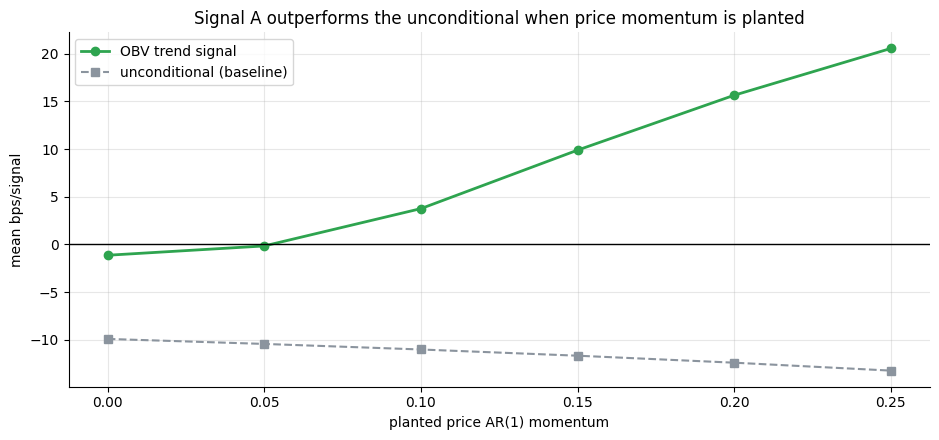

Signal A advantage over unconditional (bps):
  momentum=0.00: +8.8 bps over unconditional
  momentum=0.05: +10.3 bps over unconditional
  momentum=0.10: +14.8 bps over unconditional
  momentum=0.15: +21.6 bps over unconditional
  momentum=0.20: +28.1 bps over unconditional
  momentum=0.25: +33.8 bps over unconditional
The engine detects momentum when planted -- the real market has none.


In [6]:
moms = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]
edge_A, unc_A = [], []
for m in moms:
    b, _ = data.synthetic_daily(n_days=5000, price_momentum=m, vol_lead=0.0, seed=42)
    sig = st.signal_obv_trend(b, obv_sma_n=5)  # short window to track momentum quickly
    led = st.run_signals(b, sig, horizon=5, cost_bps=0.0)
    fwd = st.forward_returns(b, horizon=5, cost_bps=0.0).dropna()
    edge_A.append(st.summarize(led, 'ret_gross')['mean_bps'] if len(led) > 0 else 0.0)
    unc_A.append(float(fwd.mean() * 1e4))
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(moms, edge_A, 'o-', c=GREEN, lw=2, label='OBV trend signal')
ax.plot(moms, unc_A, 's--', c=GREY, lw=1.5, label='unconditional (baseline)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted price AR(1) momentum'); ax.set_ylabel('mean bps/signal')
ax.set_title('Signal A outperforms the unconditional when price momentum is planted')
ax.legend(); plt.tight_layout(); plt.show()
delta = [e - u for e, u in zip(edge_A, unc_A)]
print('Signal A advantage over unconditional (bps):')
for m, d in zip(moms, delta):
    print('  momentum=%.2f: %+.1f bps over unconditional' % (m, d))
print('The engine detects momentum when planted -- the real market has none.')

Signal A's advantage over the unconditional grows with planted momentum — confirming the engine works as a momentum detector. The real-tape verdict is therefore a statement about the **market**: modern liquid US daily data contains no exploitable OBV-based momentum structure. Volume reflects price; it does not foretell it.